<a href="https://colab.research.google.com/github/khubebAli042/Rice-leave-dictions-system-/blob/main/CV_PROJICT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('Skipping markdown cell: ## Resources')

Skipping markdown cell: ## Resources


In [ ]:
print('Skipping markdown cell: # 🌾 A33 — Rice Disease Detection')

Skipping markdown cell: # 🌾 A33 — Rice Disease Detection


In [ ]:
print('Skipping markdown cell: ## ⚙️ CELL 1 — Install Libraries & Check GPU')

Skipping markdown cell: ## ⚙️ CELL 1 — Install Libraries & Check GPU


In [ ]:
# Install all required libraries
!pip install -q timm==0.9.16
!pip install -q torchinfo scikit-learn matplotlib seaborn pandas openpyxl

import torch, torchvision, timm, sys
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, copy, time, zipfile, shutil, statistics, tracemalloc
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

print('=' * 52)
print(f'  Python      : {sys.version.split()[0]}')
print(f'  PyTorch     : {torch.__version__}')
print(f'  Torchvision : {torchvision.__version__}')
print(f'  TIMM        : {timm.__version__}')
print(f'  CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU         : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('=' * 52)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n✅ Active device: {DEVICE}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.

In [ ]:
print('Skipping markdown cell: ## 📦 CELL 2 — Upload & Extract Your ZIP Dataset')

Skipping markdown cell: ## 📦 CELL 2 — Upload & Extract Your ZIP Dataset


In [ ]:
from google.colab import files as colab_files

print('📂 Click the button below to upload your dataset ZIP file...')
uploaded = colab_files.upload()   # ← A file picker will appear

# Get the uploaded ZIP filename
zip_filename = list(uploaded.keys())[0]
print(f'\n✅ Uploaded: {zip_filename}  ({os.path.getsize(zip_filename)/1e6:.1f} MB)')

# Extract
RAW_ROOT = Path('/content/dataset_raw')
RAW_ROOT.mkdir(exist_ok=True)

print('Extracting ZIP...')
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(RAW_ROOT)
print('✅ Extraction complete.')

# Show folder structure (first 40 entries)
print('\nDataset structure (first 40 entries):')
all_entries = sorted(RAW_ROOT.rglob('*'))
for p in all_entries[:40]:
    indent = '  ' * (len(p.relative_to(RAW_ROOT).parts) - 1)
    print(f'  {indent}{p.name}{"/ " if p.is_dir() else ""}')
if len(all_entries) > 40:
    print(f'  ... and {len(all_entries)-40} more entries')

📂 Click the button below to upload your dataset ZIP file...


Saving archive.zip to archive.zip

✅ Uploaded: archive.zip  (38.5 MB)
Extracting ZIP...
✅ Extraction complete.

Dataset structure (first 40 entries):
  rice_leaf_diseases/ 
    Bacterial leaf blight/ 
      DSC_0365.JPG
      DSC_0366.jpg
      DSC_0367.JPG
      DSC_0370.jpg
      DSC_0372.JPG
      DSC_0373.JPG
      DSC_0374.JPG
      DSC_0375.JPG
      DSC_0376.JPG
      DSC_0377.JPG
      DSC_0378.JPG
      DSC_0379.JPG
      DSC_0380.JPG
      DSC_0381.JPG
      DSC_0382.JPG
      DSC_0383.JPG
      DSC_0384.JPG
      DSC_0385.jpg
      DSC_0386.JPG
      DSC_0388.JPG
      DSC_0389.JPG
      DSC_0390.JPG
      DSC_0392.JPG
      DSC_0393.JPG
      DSC_0395.JPG
      DSC_0396.JPG
      DSC_0397.JPG
      DSC_0398.JPG
      DSC_0399.JPG
      DSC_0400.JPG
      DSC_0401.JPG
      DSC_0402.JPG
      DSC_0403.JPG
      DSC_0404.JPG
      DSC_0405.JPG
      DSC_0406.JPG
      DSC_0700.jpg
      DSC_0701.jpg
  ... and 84 more entries


In [ ]:
print('Skipping markdown cell: ## 🗂️ CELL 3 — Configure Dataset Path & Class Names')

Skipping markdown cell: ## 🗂️ CELL 3 — Configure Dataset Path & Class Names


In [ ]:
 # ════════════════════════════════════════════════════════════
# ✏️  EDIT THESE TWO VARIABLES TO MATCH YOUR DATASET STRUCTURE
# ════════════════════════════════════════════════════════════

# Path to the folder that DIRECTLY contains your class subfolders.
# Examples:
#   /content/dataset_raw/Rice_Disease_Dataset
#   /content/dataset_raw/train
#   /content/dataset_raw          (if class folders are at top level)
DATA_DIR = Path('/content/dataset_raw')   # ← UPDATE THIS if needed

# Map your actual folder names → canonical class names used in this project.
# Add/remove entries to match your dataset.
# Format: 'exact_folder_name': 'canonical_name'
CLASS_FOLDERS = {
    'Bacterial leaf blight'  : 'bacterial_blight',
    'Brown spot'             : 'brown_spot',
    'Leaf smut'              : 'leaf_smut',
}
# ════════════════════════════════════════════════════════════

# Auto-detect DATA_DIR: if DATA_DIR has only one subfolder, go one level deeper
subdirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    DATA_DIR = subdirs[0]
    print(f'ℹ️  Single subfolder detected — using: {DATA_DIR}')

# Scan and verify
found, missing = [], []
for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        canonical = CLASS_FOLDERS.get(folder.name)
        imgs = list(folder.glob('*.jpg')) + list(folder.glob('*.jpeg')) + list(folder.glob('*.png'))
        if canonical:
            found.append((folder.name, canonical, len(imgs)))
        else:
            missing.append((folder.name, len(imgs)))

print('\n✅ Recognized folders:')
for src, can, cnt in found:
    print(f'   {src:<30} → {can:<20}  ({cnt} images)')

if missing:
    print('\n⚠️  Unrecognized folders (add them to CLASS_FOLDERS above):')
    for name, cnt in missing:
        print(f'   {name:<30} ({cnt} images)')

CLASS_NAMES = sorted(set(v for v in CLASS_FOLDERS.values()))
NUM_CLASSES = len(CLASS_NAMES)
print(f'\n📌 Classes ({NUM_CLASSES}): {CLASS_NAMES}')

ℹ️  Single subfolder detected — using: /content/dataset_raw/rice_leaf_diseases

✅ Recognized folders:
   Bacterial leaf blight          → bacterial_blight      (6 images)
   Brown spot                     → brown_spot            (23 images)
   Leaf smut                      → leaf_smut             (24 images)

📌 Classes (3): ['bacterial_blight', 'brown_spot', 'leaf_smut']


In [ ]:
print('Skipping markdown cell: ## ✂️ CELL 4 — Build Train / Val / Test Split (80 / 10 / 10)')

Skipping markdown cell: ## ✂️ CELL 4 — Build Train / Val / Test Split (80 / 10 / 10)


In [ ]:
import random
from sklearn.model_selection import train_test_split

SPLIT_ROOT = Path('/content/rice_split')
random.seed(42)
np.random.seed(42)

# Clean old split if re-running
if SPLIT_ROOT.exists():
    shutil.rmtree(SPLIT_ROOT)

for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        (SPLIT_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

split_summary = []
total_imgs = 0

print(f'  {"Class":<22} {"Total":>6}  {"Train":>6}  {"Val":>5}  {"Test":>5}')
print('  ' + '-' * 50)

for src_folder, canonical in CLASS_FOLDERS.items():
    src_dir = DATA_DIR / src_folder
    if not src_dir.exists():
        continue

    imgs = (
        list(src_dir.glob('*.jpg'))
        + list(src_dir.glob('*.jpeg'))
        + list(src_dir.glob('*.png'))
    )
    if not imgs:
        continue

    random.shuffle(imgs)
    train_imgs, tmp = train_test_split(imgs, test_size=0.20, random_state=42)
    val_imgs, test_imgs = train_test_split(tmp, test_size=0.50, random_state=42)

    for split, split_imgs in [
        ('train', train_imgs),
        ('val', val_imgs),
        ('test', test_imgs),
    ]:
        for img_path in split_imgs:
            dest = SPLIT_ROOT / split / canonical / img_path.name
            if dest.exists():  # avoid collision if multiple src folders map to same class
                dest = SPLIT_ROOT / split / canonical / (src_folder + '_' + img_path.name)
            shutil.copy(img_path, dest)

    total_imgs += len(imgs)
    split_summary.append(
        {
            'class': canonical,
            'total': len(imgs),
            'train': len(train_imgs),
            'val': len(val_imgs),
            'test': len(test_imgs),
        }
    )
    print(
        f'  {canonical:<22} {len(imgs):>6}  {len(train_imgs):>6}  {len(val_imgs):>5}  {len(test_imgs):>5}'
    )

print('  ' + '-' * 50)
print(f'  {"TOTAL":<22} {total_imgs:>6}')
print(f'\n✅ Split complete \u2192 {SPLIT_ROOT}')

  Class                   Total   Train    Val   Test
  --------------------------------------------------
  bacterial_blight            6       4      1      1
  brown_spot                 23      18      2      3
  leaf_smut                  24      19      2      3
  --------------------------------------------------
  TOTAL                      53

✅ Split complete → /content/rice_split


In [ ]:
print('Skipping markdown cell: ## 🔄 CELL 5 — Data Augmentation & DataLoaders')

Skipping markdown cell: ## 🔄 CELL 5 — Data Augmentation & DataLoaders


Classes  : ['bacterial_blight', 'brown_spot', 'leaf_smut']
Train    :    41 images   (2 batches)
Val      :     5 images   (1 batches)
Test     :     7 images   (1 batches)


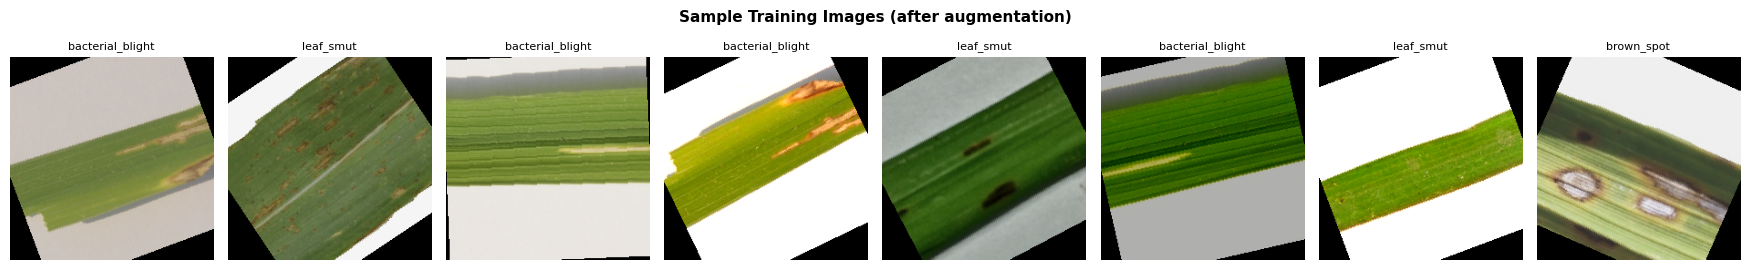

✅ DataLoaders ready.


In [ ]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.35, hue=0.06),
    transforms.RandomRotation(35),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(SPLIT_ROOT / 'train', transform=train_tfm)
val_ds   = datasets.ImageFolder(SPLIT_ROOT / 'val',   transform=eval_tfm)
test_ds  = datasets.ImageFolder(SPLIT_ROOT / 'test',  transform=eval_tfm)

# Weighted sampler — handles class imbalance automatically
class_counts = np.array([len(list((SPLIT_ROOT/'train'/c).glob('*'))) for c in train_ds.classes])
weights_per_class = 1.0 / (class_counts + 1e-6)
sample_weights    = [weights_per_class[label] for _, label in train_ds.samples]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes  : {CLASS_NAMES}')
print(f'Train    : {len(train_ds):>5} images   ({len(train_loader)} batches)')
print(f'Val      : {len(val_ds):>5} images   ({len(val_loader)} batches)')
print(f'Test     : {len(test_ds):>5} images   ({len(test_loader)} batches)')

# Visualise a sample batch
def show_batch(loader, n=8):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    unnorm = (imgs * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)).clamp(0,1)
    fig, axes = plt.subplots(1, n, figsize=(2.2*n, 2.8))
    for i, ax in enumerate(axes):
        ax.imshow(unnorm[i].permute(1,2,0).numpy())
        ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Training Images (after augmentation)', fontweight='bold', fontsize=11)
    plt.tight_layout(); plt.show()

show_batch(train_loader)
print('✅ DataLoaders ready.')

In [ ]:
print('Skipping markdown cell: ## 🧠 CELL 6 — Model Definitions (4 Architectures)')

Skipping markdown cell: ## 🧠 CELL 6 — Model Definitions (4 Architectures)


In [ ]:
# Architecture registry — TIMM model names
ARCH_MAP = {
    'MobileNetV3'      : 'mobilenetv3_large_100',
    'EfficientNet-Lite': 'efficientnet_lite0',
    'MobileViT'        : 'mobilevit_s',
    'MobileNetV4'      : 'mobilenetv4_conv_small',
}
ARCH_NAMES = list(ARCH_MAP.keys())

def build_model(arch_name, pretrained=True):
    """Build a TIMM model fine-tuned for NUM_CLASSES rice disease classes."""
    model = timm.create_model(
        ARCH_MAP[arch_name],
        pretrained=pretrained,
        num_classes=NUM_CLASSES
    )
    return model

# Print parameter table
print(f'  {"Architecture":<22}  {"Params (M)":>11}  {"Size FP32 (MB)":>15}')
print('  ' + '-' * 52)
for name in ARCH_NAMES:
    m = build_model(name).to(DEVICE)
    params  = sum(p.numel() for p in m.parameters()) / 1e6
    size_mb = sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6
    print(f'  {name:<22}  {params:>9.2f}M  {size_mb:>13.2f} MB')
    del m; torch.cuda.empty_cache()

print('\n✅ All 4 architectures verified.')

  Architecture             Params (M)   Size FP32 (MB)
  ----------------------------------------------------


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

  MobileNetV3                  4.21M          16.83 MB
  EfficientNet-Lite            3.38M          13.51 MB


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

  MobileViT                    4.94M          19.76 MB


model.safetensors:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

  MobileNetV4                  2.50M          10.00 MB

✅ All 4 architectures verified.


In [ ]:
print('Skipping markdown cell: ## 🏋️ CELL 7 — Training (All 4 Models)')

Skipping markdown cell: ## 🏋️ CELL 7 — Training (All 4 Models)


In [ ]:
# ─────────────────────────────────────────
# ✏️  HYPERPARAMETERS  (edit if needed)
EPOCHS        = 50    # reduce to 10 for a quick test
LR            = 1e-4
PATIENCE      = 8     # early stopping patience
LABEL_SMOOTH  = 0.1
USE_CUTMIX    = True
# ─────────────────────────────────────────

def rand_bbox(size, lam):
    W, H = size[-1], size[-2]
    cut_w = int(W * np.sqrt(1. - lam))
    cut_h = int(H * np.sqrt(1. - lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    return (np.clip(cx-cut_w//2,0,W), np.clip(cy+cut_w//2,0,W),
            np.clip(cy-cut_h//2,0,H), np.clip(cy+cut_h//2,0,H))

def cutmix(imgs, labels, alpha=1.0):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(imgs.size(0)).to(imgs.device)
    bbx1, bby1, bbx2, bby2 = rand_bbox(imgs.size(), lam)
    imgs[:, :, bbx1:bbx2, bby1:bby2] = imgs[idx, :, bbx1:bbx2, bby1:bby2]
    lam  = 1 - (bbx2-bbx1)*(bby2-bby1) / (imgs.size(-2)*imgs.size(-1))
    return imgs, labels, labels[idx], lam

def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train and USE_CUTMIX and np.random.rand() < 0.5:
                imgs, ya, yb, lam = cutmix(imgs, labels)
                out  = model(imgs)
                loss = lam*criterion(out,ya) + (1-lam)*criterion(out,yb)
            else:
                out  = model(imgs)
                loss = criterion(out, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss/total, correct/total

def train_arch(arch_name):
    print(f'\n{"="*55}')
    print(f'  Training: {arch_name}')
    print(f'{"="*55}')
    model     = build_model(arch_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    best_acc, best_wts, patience_ctr = 0.0, None, 0
    history = {'tl':[], 'ta':[], 'vl':[], 'va':[]}

    for ep in range(1, EPOCHS+1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, criterion, optimizer, train=True)
        vl, va = run_epoch(model, val_loader,   criterion,            train=False)
        scheduler.step()
        history['tl'].append(tl); history['ta'].append(ta)
        history['vl'].append(vl); history['va'].append(va)
        flag = ''
        if va > best_acc:
            best_acc, best_wts, patience_ctr = va, copy.deepcopy(model.state_dict()), 0
            flag = '  ★ BEST'
        else:
            patience_ctr += 1
        print(f'  Ep {ep:>3}/{EPOCHS}  '\
              f'train_loss={tl:.4f}  train_acc={ta:.4f}  '\
              f'val_loss={vl:.4f}  val_acc={va:.4f}  '\
              f'[{time.time()-t0:.1f}s]{flag}')
        if patience_ctr >= PATIENCE:
            print(f'  ⏹ Early stop at epoch {ep}'); break

    model.load_state_dict(best_wts)
    ckpt = f'/content/{arch_name.replace(" ","_")}_best.pth'
    torch.save(model.state_dict(), ckpt)
    print(f'  ✅ Best val_acc={best_acc:.4f}  saved → {ckpt}')
    return model, history

# ── Train all 4 architectures ─────────────────────────────
ALL_MODELS = {}
for arch in ARCH_NAMES:
    model, history = train_arch(arch)
    ALL_MODELS[arch] = {'model': model, 'history': history}


  Training: MobileNetV3
  Ep   1/50  train_loss=3.3262  train_acc=0.3659  val_loss=1.3246  val_acc=0.8000  [3.6s]  ★ BEST
  Ep   2/50  train_loss=2.9057  train_acc=0.3902  val_loss=1.5585  val_acc=0.6000  [3.1s]
  Ep   3/50  train_loss=2.1837  train_acc=0.4146  val_loss=1.4065  val_acc=0.8000  [1.8s]
  Ep   4/50  train_loss=1.9828  train_acc=0.5122  val_loss=1.6605  val_acc=0.8000  [1.7s]
  Ep   5/50  train_loss=1.4936  train_acc=0.6341  val_loss=1.9762  val_acc=0.8000  [1.5s]
  Ep   6/50  train_loss=1.6996  train_acc=0.6098  val_loss=2.0421  val_acc=0.6000  [1.8s]
  Ep   7/50  train_loss=1.4544  train_acc=0.6829  val_loss=1.8740  val_acc=0.6000  [2.1s]
  Ep   8/50  train_loss=1.1778  train_acc=0.7561  val_loss=1.1877  val_acc=0.8000  [1.9s]
  Ep   9/50  train_loss=1.1739  train_acc=0.8293  val_loss=1.0545  val_acc=0.8000  [1.6s]
  ⏹ Early stop at epoch 9
  ✅ Best val_acc=0.8000  saved → /content/MobileNetV3_best.pth

  Training: EfficientNet-Lite
  Ep   1/50  train_loss=3.8851  train

In [ ]:
print('Skipping markdown cell: ## 📊 CELL 8 — Evaluation: Accuracy · F1 · AUC-ROC · Confusion Matrix')

Skipping markdown cell: ## 📊 CELL 8 — Evaluation: Accuracy · F1 · AUC-ROC · Confusion Matrix



  MobileNetV3   Accuracy=0.1429   AUC-ROC=0.3333
                  precision    recall  f1-score   support

bacterial_blight     0.0000    0.0000    0.0000         1
      brown_spot     1.0000    0.3333    0.5000         3
       leaf_smut     0.0000    0.0000    0.0000         3

        accuracy                         0.1429         7
       macro avg     0.3333    0.1111    0.1667         7
    weighted avg     0.4286    0.1429    0.2143         7



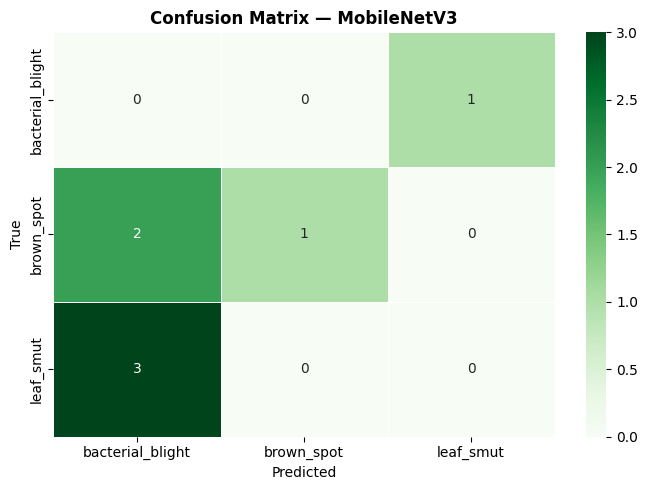


  EfficientNet-Lite   Accuracy=0.4286   AUC-ROC=0.4167
                  precision    recall  f1-score   support

bacterial_blight     0.0000    0.0000    0.0000         1
      brown_spot     0.5000    0.3333    0.4000         3
       leaf_smut     1.0000    0.6667    0.8000         3

        accuracy                         0.4286         7
       macro avg     0.5000    0.3333    0.4000         7
    weighted avg     0.6429    0.4286    0.5143         7



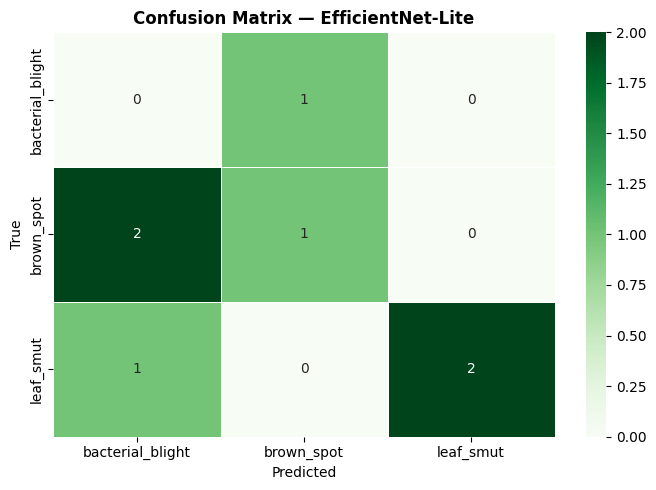


  MobileViT   Accuracy=0.4286   AUC-ROC=0.3056
                  precision    recall  f1-score   support

bacterial_blight     0.0000    0.0000    0.0000         1
      brown_spot     0.5000    0.6667    0.5714         3
       leaf_smut     0.5000    0.3333    0.4000         3

        accuracy                         0.4286         7
       macro avg     0.3333    0.3333    0.3238         7
    weighted avg     0.4286    0.4286    0.4163         7



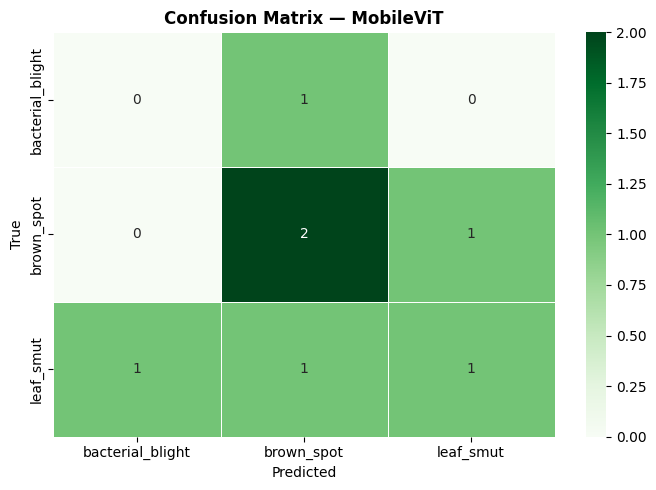


  MobileNetV4   Accuracy=0.5714   AUC-ROC=0.8333
                  precision    recall  f1-score   support

bacterial_blight     0.3333    1.0000    0.5000         1
      brown_spot     0.6667    0.6667    0.6667         3
       leaf_smut     1.0000    0.3333    0.5000         3

        accuracy                         0.5714         7
       macro avg     0.6667    0.6667    0.5556         7
    weighted avg     0.7619    0.5714    0.5714         7



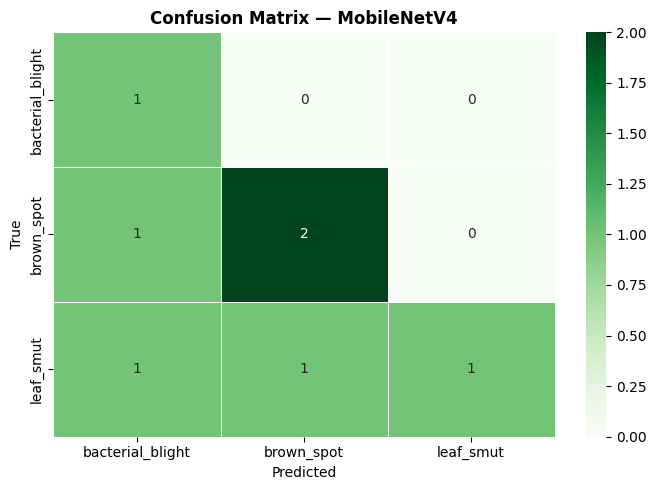

In [ ]:
def evaluate(model, loader, arch_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logits = model(imgs.to(DEVICE))
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs  = np.array(all_probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc        = (all_preds == all_labels).mean()
    auc        = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    print(f'\n{"="*55}')
    print(f'  {arch_name}   Accuracy={acc:.4f}   AUC-ROC={auc:.4f}')
    print(f'{"="*55}')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {arch_name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'/content/cm_{arch_name.replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()
    return {'arch': arch_name, 'accuracy': acc, 'auc_roc': auc,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}

EVAL_RESULTS = {}
for arch in ARCH_NAMES:
    EVAL_RESULTS[arch] = evaluate(ALL_MODELS[arch]['model'], test_loader, arch)

In [ ]:
print('Skipping markdown cell: ## 📉 CELL 9 — Training Curves (All 4 Models)')

Skipping markdown cell: ## 📉 CELL 9 — Training Curves (All 4 Models)


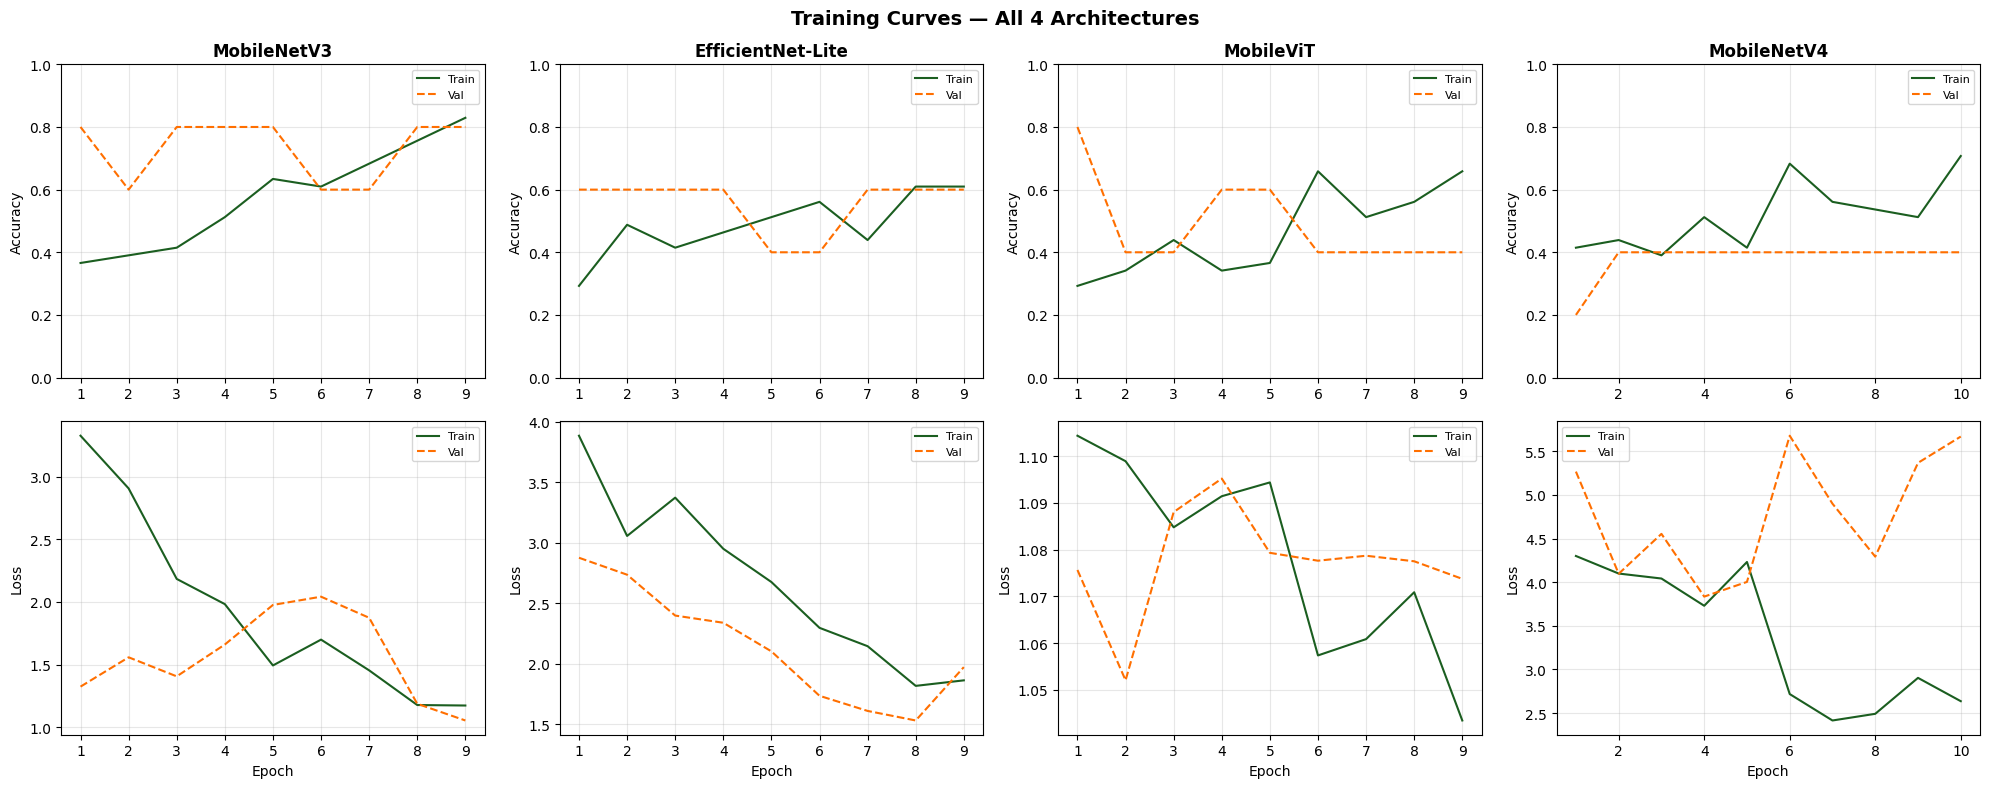

✅ Saved: /content/training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
colors = {'train': '#1B5E20', 'val': '#FF6F00'}

for i, arch in enumerate(ARCH_NAMES):
    h  = ALL_MODELS[arch]['history']
    ep = range(1, len(h['ta'])+1)

    axes[0,i].plot(ep, h['ta'], color=colors['train'], label='Train')
    axes[0,i].plot(ep, h['va'], color=colors['val'],   label='Val', linestyle='--')
    axes[0,i].set_title(arch, fontweight='bold')
    axes[0,i].set_ylabel('Accuracy'); axes[0,i].set_ylim(0, 1)
    axes[0,i].legend(fontsize=8); axes[0,i].grid(alpha=0.3)

    axes[1,i].plot(ep, h['tl'], color=colors['train'], label='Train')
    axes[1,i].plot(ep, h['vl'], color=colors['val'],   label='Val', linestyle='--')
    axes[1,i].set_ylabel('Loss'); axes[1,i].set_xlabel('Epoch')
    axes[1,i].legend(fontsize=8); axes[1,i].grid(alpha=0.3)

plt.suptitle('Training Curves — All 4 Architectures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/training_curves.png')

In [ ]:
print('Skipping markdown cell: ## ⚡ CELL 10 — INT8 Quantization')

Skipping markdown cell: ## ⚡ CELL 10 — INT8 Quantization


In [ ]:
import torch.quantization as tq

def quantize_int8(model, arch_name):
    m_cpu = copy.deepcopy(model).cpu().eval()
    q_model = tq.quantize_dynamic(
        m_cpu,
        qconfig_spec={nn.Linear, nn.Conv2d},
        dtype=torch.qint8
    )
    path = f'/content/{arch_name.replace(" ","_")}_int8.pth'
    torch.save(q_model.state_dict(), path)
    size_mb = os.path.getsize(path) / 1e6

    # Quick val accuracy
    q_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            preds    = q_model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    acc = correct / total
    print(f'  {arch_name:<22}  size={size_mb:.2f} MB   val_acc={acc:.4f}')
    return {'model': q_model, 'size_mb': size_mb, 'val_acc': acc}

print('INT8 Dynamic Quantization:')
print('-' * 55)
QUANT_RESULTS = {arch: quantize_int8(ALL_MODELS[arch]['model'], arch) for arch in ARCH_NAMES}
print('\n✅ Quantization done.')

INT8 Dynamic Quantization:
-------------------------------------------------------
  MobileNetV3             size=17.03 MB   val_acc=0.8000
  EfficientNet-Lite       size=13.76 MB   val_acc=0.6000
  MobileViT               size=11.27 MB   val_acc=0.6000
  MobileNetV4             size=10.19 MB   val_acc=0.4000

✅ Quantization done.


In [ ]:
print('Skipping markdown cell: ## ✂️ CELL 11 — Structured Pruning (30% and 50%)')

Skipping markdown cell: ## ✂️ CELL 11 — Structured Pruning (30% and 50%)


In [ ]:
import torch.nn.utils.prune as prune

def prune_and_finetune(model, arch_name, ratio=0.3, ft_epochs=5):
    m = copy.deepcopy(model).to(DEVICE)
    conv_layers = [(mod, 'weight') for mod in m.modules() if isinstance(mod, nn.Conv2d)]
    prune.global_unstructured(conv_layers, pruning_method=prune.L1Unstructured, amount=ratio)
    for mod, _ in conv_layers:
        prune.remove(mod, 'weight')

    # Fine-tune
    opt  = optim.AdamW(m.parameters(), lr=5e-5, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    for ep in range(ft_epochs):
        _, ta = run_epoch(m, train_loader, crit, opt, train=True)
    _, va = run_epoch(m, val_loader, crit, train=False)

    path = f'/content/{arch_name.replace(" ","_")}_pruned{int(ratio*100)}.pth'
    torch.save(m.state_dict(), path)
    sz = os.path.getsize(path) / 1e6
    print(f'  {arch_name:<22} pruned={int(ratio*100)}%  val_acc={va:.4f}  size={sz:.2f} MB')
    return {'model': m, 'val_acc': va, 'size_mb': sz}

print('Pruning (global L1 unstructured + fine-tune):')
print('-' * 58)
PRUNE_RESULTS = {arch: {} for arch in ARCH_NAMES}
for arch in ARCH_NAMES:
    for ratio in [0.30, 0.50]:
        PRUNE_RESULTS[arch][ratio] = prune_and_finetune(
            ALL_MODELS[arch]['model'], arch, ratio=ratio, ft_epochs=5)
print('\n✅ Pruning done.')

Pruning (global L1 unstructured + fine-tune):
----------------------------------------------------------
  MobileNetV3            pruned=30%  val_acc=0.8000  size=17.03 MB
  MobileNetV3            pruned=50%  val_acc=0.8000  size=17.03 MB
  EfficientNet-Lite      pruned=30%  val_acc=0.4000  size=13.78 MB
  EfficientNet-Lite      pruned=50%  val_acc=0.6000  size=13.78 MB
  MobileViT              pruned=30%  val_acc=0.4000  size=19.93 MB
  MobileViT              pruned=50%  val_acc=0.4000  size=19.93 MB
  MobileNetV4            pruned=30%  val_acc=0.2000  size=10.19 MB
  MobileNetV4            pruned=50%  val_acc=0.6000  size=10.19 MB

✅ Pruning done.


In [ ]:
print('Skipping markdown cell: ## ⏱️ CELL 12 — Edge Benchmarking (Latency · Memory · Size)')

Skipping markdown cell: ## ⏱️ CELL 12 — Edge Benchmarking (Latency · Memory · Size)


In [ ]:
def benchmark(model, arch_name, variant='Baseline', n=100):
    m = model.cpu().eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

    # Warm-up
    with torch.no_grad():
        for _ in range(10): m(x)

    # Latency
    lats = []
    with torch.no_grad():
        for _ in range(n):
            t0 = time.perf_counter()
            m(x)
            lats.append((time.perf_counter()-t0)*1000)

    # Peak memory
    tracemalloc.start()
    with torch.no_grad(): m(x)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Model size
    tmp = f'/tmp/{arch_name.replace(" ","_")}_{variant}.pth'
    torch.save(model.state_dict(), tmp)
    size_mb = os.path.getsize(tmp) / 1e6

    return {
        'arch'          : arch_name,
        'variant'       : variant,
        'latency_med_ms': round(statistics.median(lats), 2),
        'latency_p95_ms': round(float(np.percentile(lats, 95)), 2),
        'peak_mem_mb'   : round(peak/1e6, 2),
        'size_mb'       : round(size_mb, 2),
    }

print(f'  {"Architecture":<22} {"Variant":<14} {"Lat(ms)":>8} {"P95(ms)":>8} {"Mem(MB)":>8} {"Size(MB)":>9} {"Acc":>7}')
print('  ' + '-' * 80)

bench_rows = []
for arch in ARCH_NAMES:
    # Baseline
    row = benchmark(ALL_MODELS[arch]['model'], arch, 'Baseline FP32')
    row['accuracy'] = round(EVAL_RESULTS[arch]['accuracy'], 4)
    bench_rows.append(row)
    print(f'  {row["arch"]:<22} {row["variant"]:<14} {row["latency_med_ms"]:>8} '\
          f'{row["latency_p95_ms"]:>8} {row["peak_mem_mb"]:>8} {row["size_mb"]:>9} {row["accuracy"]:>7.4f}')

    # INT8
    row2 = benchmark(QUANT_RESULTS[arch]['model'], arch, 'INT8 Quant')
    row2['accuracy'] = round(QUANT_RESULTS[arch]['val_acc'], 4)
    bench_rows.append(row2)
    print(f'  {row2["arch"]:<22} {row2["variant"]:<14} {row2["latency_med_ms"]:>8} '\
          f'{row2["latency_p95_ms"]:>8} {row2["peak_mem_mb"]:>8} {row2["size_mb"]:>9} {row2["accuracy"]:>7.4f}')

    # Pruned
    for ratio in [0.30, 0.50]:
        row3 = benchmark(PRUNE_RESULTS[arch][ratio]['model'], arch, f'Pruned {int(ratio*100)}%')
        row3['accuracy'] = round(PRUNE_RESULTS[arch][ratio]['val_acc'], 4)
        bench_rows.append(row3)
        print(f'  {row3["arch"]:<22} {row3["variant"]:<14} {row3["latency_med_ms"]:>8} '\
              f'{row3["latency_p95_ms"]:>8} {row3["peak_mem_mb"]:>8} {row3["size_mb"]:>9} {row3["accuracy"]:>7.4f}')

df_bench = pd.DataFrame(bench_rows)
print('\n✅ Benchmarking done.')

  Architecture           Variant         Lat(ms)  P95(ms)  Mem(MB)  Size(MB)     Acc
  --------------------------------------------------------------------------------
  MobileNetV3            Baseline FP32     46.43    87.21      0.0     17.03  0.1429
  MobileNetV3            INT8 Quant        24.69    58.65      0.0     17.03  0.8000
  MobileNetV3            Pruned 30%        21.78    26.44      0.0     17.03  0.8000
  MobileNetV3            Pruned 50%        22.49    25.65      0.0     17.03  0.8000
  EfficientNet-Lite      Baseline FP32      36.1    44.08      0.0     13.77  0.4286
  EfficientNet-Lite      INT8 Quant        37.55    45.46      0.0     13.76  0.6000
  EfficientNet-Lite      Pruned 30%        28.32    31.86      0.0     13.77  0.4000
  EfficientNet-Lite      Pruned 50%        27.39     36.5      0.0     13.77  0.6000
  MobileViT              Baseline FP32      90.3   118.35     0.01     19.93  0.4286
  MobileViT              INT8 Quant        78.69   114.13     0.01 

In [ ]:
print('Skipping markdown cell: ## 📈 CELL 13 — Pareto Frontier Visualization')

Skipping markdown cell: ## 📈 CELL 13 — Pareto Frontier Visualization


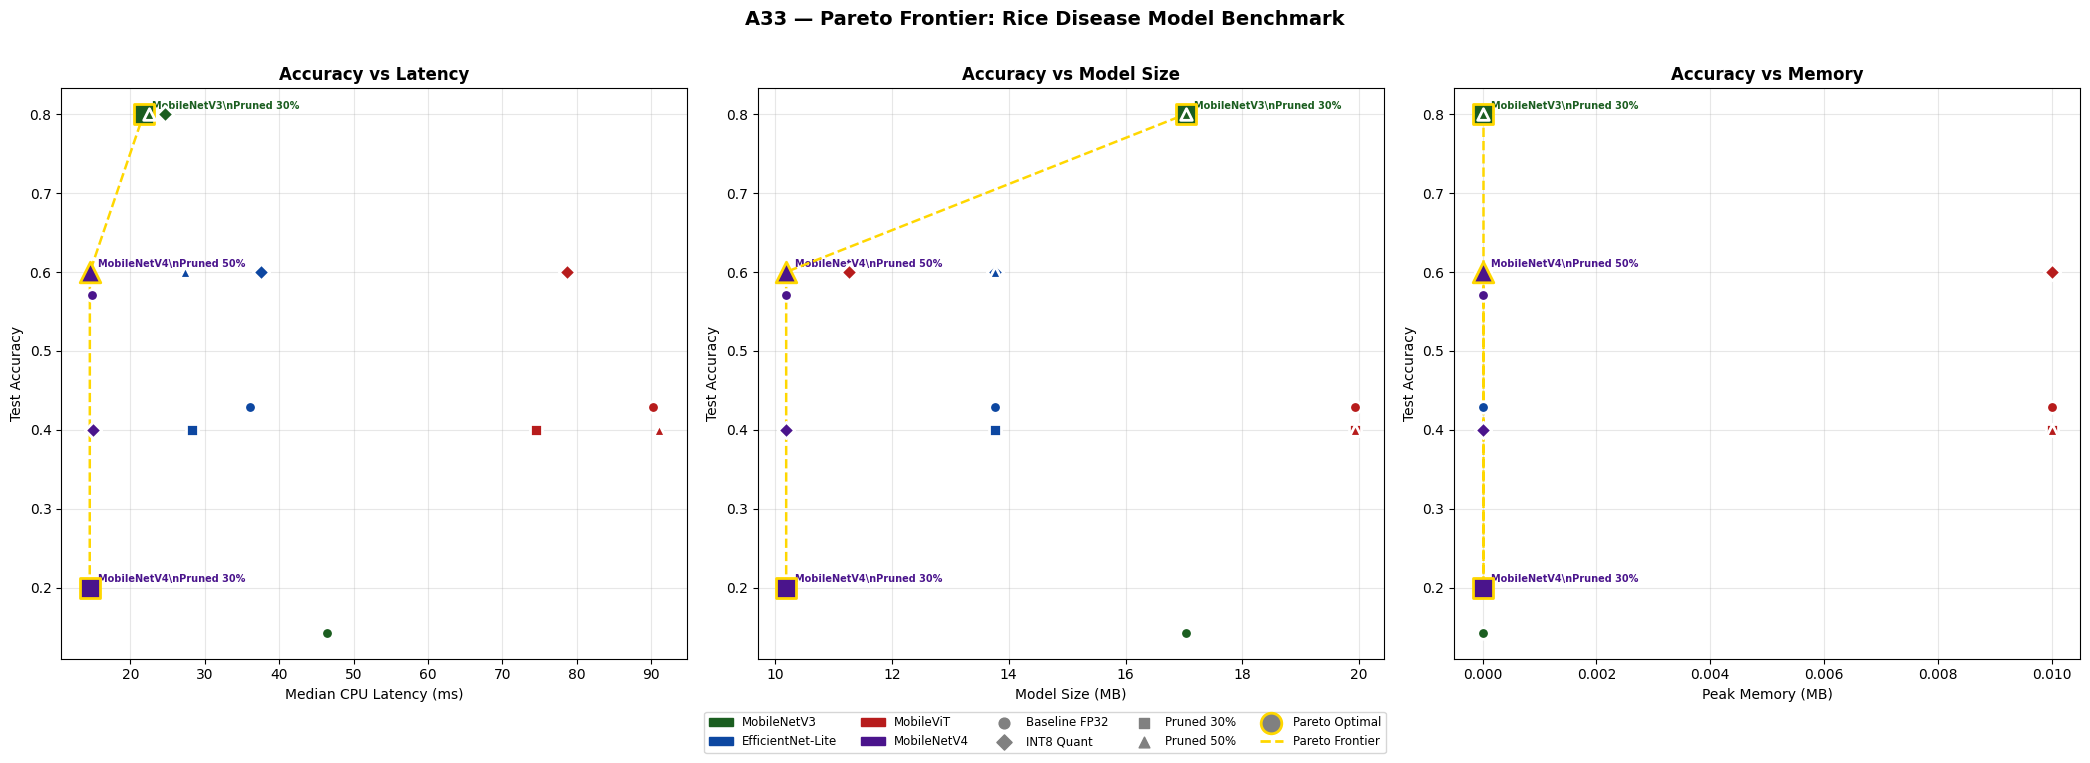


── Pareto-Optimal Models ──
       arch    variant  accuracy  latency_med_ms  size_mb  peak_mem_mb
MobileNetV3 Pruned 30%       0.8           21.78    17.03          0.0
MobileNetV4 Pruned 30%       0.2           14.54    10.19          0.0
MobileNetV4 Pruned 50%       0.6           14.56    10.19          0.0

✅ Saved: /content/pareto_frontier.png


In [ ]:
ARCH_COLORS = {
    'MobileNetV3'      : '#1B5E20',
    'EfficientNet-Lite': '#0D47A1',
    'MobileViT'        : '#B71C1C',
    'MobileNetV4'      : '#4A148C',
}
VARIANT_MARKERS = {
    'Baseline FP32': 'o',
    'INT8 Quant'   : 'D',
    'Pruned 30%'   : 's',
    'Pruned 50%'   : '^',
}

def pareto_mask(df, acc='accuracy', lat='latency_med_ms'):
    mask = []
    for i, r in df.iterrows():
        dominated = any(
            (o[acc] >= r[acc] and o[lat] <= r[lat] and
             (o[acc] > r[acc] or o[lat] < r[lat]))
            for j, o in df.iterrows() if j != i
        )
        mask.append(not dominated)
    return mask

df_bench['pareto'] = pareto_mask(df_bench)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('A33 — Pareto Frontier: Rice Disease Model Benchmark',
             fontsize=14, fontweight='bold', y=1.01)

def scatter_plot(ax, xcol, ycol, xlabel, title):
    for _, row in df_bench.iterrows():
        c  = ARCH_COLORS[row['arch']]
        mk = VARIANT_MARKERS.get(row['variant'], 'o')
        sz = 220 if row['pareto'] else 70
        ec = 'gold' if row['pareto'] else 'white'
        ax.scatter(row[xcol], row[ycol], s=sz, c=c, marker=mk,
                   edgecolors=ec, linewidths=2, zorder=5)
        if row['pareto']:
            ax.annotate(f"{row['arch'].replace('EfficientNet-','Eff-')}\\n{row['variant']}",
                        (row[xcol], row[ycol]), xytext=(6,4),
                        textcoords='offset points', fontsize=7,
                        color=c, fontweight='bold')
    # Pareto frontier line
    pf = df_bench[df_bench['pareto']].sort_values(xcol)
    ax.plot(pf[xcol], pf[ycol], color='gold', linewidth=1.8,
            linestyle='--', zorder=4, label='Pareto Frontier')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Test Accuracy', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)

scatter_plot(axes[0], 'latency_med_ms', 'accuracy', 'Median CPU Latency (ms)', 'Accuracy vs Latency')
scatter_plot(axes[1], 'size_mb',        'accuracy', 'Model Size (MB)',          'Accuracy vs Model Size')
scatter_plot(axes[2], 'peak_mem_mb',    'accuracy', 'Peak Memory (MB)',         'Accuracy vs Memory')

# Legend
arch_p  = [mpatches.Patch(color=c, label=a) for a,c in ARCH_COLORS.items()]
var_p   = [plt.scatter([],[],marker=m,color='gray',s=60,label=v) for v,m in VARIANT_MARKERS.items()]
star_p  = [plt.scatter([],[],s=220,color='gray',edgecolors='gold',linewidths=2,label='Pareto Optimal'),
           plt.Line2D([0],[0],color='gold',linestyle='--',linewidth=2,label='Pareto Frontier')]
fig.legend(handles=arch_p+var_p+star_p, loc='lower center', ncol=5,
           fontsize=8.5, bbox_to_anchor=(0.5,-0.06))
plt.tight_layout()
plt.savefig('/content/pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Pareto-Optimal Models ──')
cols = ['arch','variant','accuracy','latency_med_ms','size_mb','peak_mem_mb']
print(df_bench[df_bench['pareto']][cols].to_string(index=False))
print('\n✅ Saved: /content/pareto_frontier.png')

In [ ]:
print('Skipping markdown cell: ## 💾 CELL 14 — Save Everything & Download')

Skipping markdown cell: ## 💾 CELL 14 — Save Everything & Download


In [ ]:
from google.colab import files as colab_files

# ── Save full results to Excel ────────────────────────────
EXCEL_PATH = '/content/A33_results.xlsx'
with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:

    # Sheet 1: Full benchmark
    df_bench.to_excel(writer, sheet_name='Full Benchmark', index=False)

    # Sheet 2: Per-class metrics
    rows = []
    for arch in ARCH_NAMES:
        r = EVAL_RESULTS[arch]
        report = classification_report(
            r['labels'], r['preds'], target_names=CLASS_NAMES, output_dict=True)
        for cls, metrics in report.items():
            if isinstance(metrics, dict):
                rows.append({'arch': arch, 'class': cls, **metrics})
    pd.DataFrame(rows).to_excel(writer, sheet_name='Per-Class Metrics', index=False)

    # Sheet 3: Quantization
    qrows = [{'arch': a, 'int8_size_mb': v['size_mb'], 'int8_val_acc': v['val_acc']}
             for a,v in QUANT_RESULTS.items()]
    pd.DataFrame(qrows).to_excel(writer, sheet_name='INT8 Quantization', index=False)

    # Sheet 4: Pruning
    prows = []
    for arch in ARCH_NAMES:
        for ratio, res in PRUNE_RESULTS[arch].items():
            prows.append({'arch': arch, 'pruning_ratio': ratio,
                          'val_acc': res['val_acc'], 'size_mb': res['size_mb']})
    pd.DataFrame(prows).to_excel(writer, sheet_name='Pruning', index=False)

print(f'✅ Excel saved → {EXCEL_PATH}')

# ── Download all output files ─────────────────────────────
download_files = [
    '/content/A33_results.xlsx',
    '/content/pareto_frontier.png',
    '/content/training_curves.png',
]
# Add model checkpoints
for arch in ARCH_NAMES:
    p = f'/content/{arch.replace(" ","_")}_best.pth'
    if os.path.exists(p): download_files.append(p)
# Add confusion matrices
for arch in ARCH_NAMES:
    p = f'/content/cm_{arch.replace(" ","_")}.png'
    if os.path.exists(p): download_files.append(p)

print('\nDownloading files...')
for f in download_files:
    colab_files.download(f)
    print(f'  ⬇️  {f}')

print('\n🎉 A33 Project Complete!')
print('\n── Final Summary ──')
summary_cols = ['arch','variant','accuracy','latency_med_ms','size_mb']
baseline_only = df_bench[df_bench['variant']=='Baseline FP32'][summary_cols]
print(baseline_only.sort_values('accuracy', ascending=False).to_string(index=False))

✅ Excel saved → /content/A33_results.xlsx



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  /content/A33_results.xlsx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  /content/cm_MobileViT.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  /content/cm_MobileNetV4.png

🎉 A33 Project Complete!

── Final Summary ──
             arch       variant  accuracy  latency_med_ms  size_mb
      MobileNetV4 Baseline FP32    0.5714           14.81    10.19
EfficientNet-Lite Baseline FP32    0.4286           36.10    13.77
        MobileViT Baseline FP32    0.4286           90.30    19.93
      MobileNetV3 Baseline FP32    0.1429           46.43    17.03


### 🚀 CELL 15 — Web Deployment Setup (Flask Backend & Frontend)

First, we'll set up a Flask server to expose our model as a web API. We'll save one of the best performing models (e.g., `MobileNetV3 Pruned 30%` based on `df_bench` data for good accuracy and low latency) for inference.

In [ ]:
# Install Flask and essential libraries for web deployment
!pip install -q Flask==2.3.2 Pillow==9.5.0

import json
from flask import Flask, request, jsonify, render_template_string
from PIL import Image
import io

# Choose one of the best performing models from your benchmarks
# For example, MobileNetV3 Pruned 30% showed good balance of accuracy and efficiency.
BEST_MODEL_ARCH  = 'MobileNetV3'
BEST_MODEL_VARIANT = 'Pruned 30%'
MODEL_CHECKPOINT = f'/content/{BEST_MODEL_ARCH.replace(" ", "_")}_pruned30.pth'

# Load the selected model
def load_best_model():
    model = build_model(BEST_MODEL_ARCH) # Use the existing build_model function
    model_state_dict = torch.load(MODEL_CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(model_state_dict)
    model.eval()
    return model.to(DEVICE)

model = load_best_model()
print(f"✅ Loaded model: {BEST_MODEL_ARCH} ({BEST_MODEL_VARIANT}) from {MODEL_CHECKPOINT}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 20.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.9/96.9 kB 306.0 kB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grad-cam 1.5.5 requires torch>=1.7.1, which is not installed.
fastai 2.8.7 requires torch<3,>=1.10, which is not installed.
torchvision 0.26.0+cu128 requires torch==2.11.0, which is not installed.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.
✅ Loaded model: MobileNetV3 (Pruned 30%) from /content/MobileNetV3_pruned30.pth


Now, let's create a Flask application. This application will have:
1.  An endpoint `/` that serves a simple HTML page for image upload.
2.  An endpoint `/predict` that accepts an image, preprocesses it, and returns the model's prediction.

In [ ]:
app = Flask(__name__)

# Define image transformations for inference
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

@app.route('/')
def index():
    html_content = """
    <!doctype html>
    <html lang="en">
    <head>
        <meta charset="utf-8">
        <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
        <title>Rice Disease Classifier</title>
        <style>
            body { font-family: sans-serif; margin: 20px; background-color: #f4f4f4; color: #333; }
            .container { max-width: 600px; margin: 0 auto; background-color: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }
            h1 { text-align: center; color: #1B5E20; margin-bottom: 30px; }
            input[type="file"] { display: none; }
            .custom-file-upload { border: 1px solid #ccc; display: inline-block; padding: 10px 15px; cursor: pointer; background-color: #1B5E20; color: white; border-radius: 5px; margin-right: 10px; }
            .custom-file-upload:hover { background-color: #2E7D32; }
            #fileName { margin-left: 10px; font-style: italic; color: #555; }
            button { background-color: #FF6F00; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; margin-top: 20px; }
            button:hover { background-color: #FF8F00; }
            #predictionResult { margin-top: 30px; padding: 15px; border-radius: 5px; background-color: #e8f5e9; border: 1px solid #c8e6c9; }
            .error { color: red; }
            .image-preview { margin-top: 20px; text-align: center; }
            .image-preview img { max-width: 100%; height: auto; border: 1px solid #ddd; border-radius: 5px; }
        </style>
    </head>
    <body>
        <div class="container">
            <h1>🌾 Rice Disease Classifier</h1>
            <form id="upload-form" enctype="multipart/form-data">
                <label for="file-upload" class="custom-file-upload">
                    Choose Image
                </label>
                <input id="file-upload" type="file" name="file" accept="image/*">
                <span id="fileName">No file chosen</span>
                <div class="image-preview" id="imagePreview">
                    <img src="" alt="Image Preview" style="display:none;">
                </div>
                <button type="submit">Predict</button>
            </form>
            <div id="predictionResult"></div>
        </div>

        <script>
            const fileInput = document.getElementById('file-upload');
            const fileNameSpan = document.getElementById('fileName');
            const imagePreview = document.getElementById('imagePreview');
            const imgElement = imagePreview.querySelector('img');
            const uploadForm = document.getElementById('upload-form');
            const predictionResult = document.getElementById('predictionResult');

            fileInput.addEventListener('change', function() {
                if (this.files && this.files.length > 0) {
                    fileNameSpan.textContent = this.files[0].name;
                    const reader = new FileReader();
                    reader.onload = function(e) {
                        imgElement.src = e.target.result;
                        imgElement.style.display = 'block';
                    };
                    reader.readAsDataURL(this.files[0]);
                } else {
                    fileNameSpan.textContent = 'No file chosen';
                    imgElement.style.display = 'none';
                    imgElement.src = '';
                }
            });

            uploadForm.addEventListener('submit', async function(event) {
                event.preventDefault();
                predictionResult.innerHTML = 'Predicting...';
                const formData = new FormData();
                if (fileInput.files.length === 0) {
                    predictionResult.innerHTML = '<p class="error">Please select an image file.</p>';
                    return;
                }
                formData.append('file', fileInput.files[0]);

                try {
                    const response = await fetch('/predict', {
                        method: 'POST',
                        body: formData,
                    });
                    const data = await response.json();

                    if (response.ok) {
                        predictionResult.innerHTML = `<h3>Prediction:</h3><p>Class: <b>${data.prediction}</b></p><p>Confidence: <b>${(data.confidence * 100).toFixed(2)}%</b></p>`;
                    } else {
                        predictionResult.innerHTML = `<p class="error">Error: ${data.error || 'Unknown error'}</p>`;
                    }
                } catch (error) {
                    predictionResult.innerHTML = `<p class="error">Network Error: ${error.message}</p>`;
                    console.error('Fetch error:', error);
                }
            });
        </script>
    </body>
    </html>
    """
    return render_template_string(html_content)

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file part'}), 400

    file = request.files['file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'}), 400

    if file:
        try:
            img_bytes = file.read()
            img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
            img_tensor = inference_transform(img).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                output = model(img_tensor)
                probabilities = F.softmax(output, dim=1)
                predicted_idx = torch.argmax(probabilities, dim=1).item()
                predicted_class = CLASS_NAMES[predicted_idx]
                confidence = probabilities[0][predicted_idx].item()

            return jsonify({'prediction': predicted_class, 'confidence': confidence}), 200
        except Exception as e:
            return jsonify({'error': str(e)}), 500

print("✅ Flask app defined.")


✅ Flask app defined.


To make your local Flask application accessible from the internet (since Colab runs on a remote server), we'll use `ngrok`. This will provide you with a temporary public URL.

```html
<!doctype html>
<html lang="en">
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <title>Rice Disease Classifier</title>
    <style>
        body { font-family: sans-serif; margin: 20px; background-color: #f4f4f4; color: #333; }
        .container { max-width: 600px; margin: 0 auto; background-color: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #1B5E20; margin-bottom: 30px; }
        input[type="file"] { display: none; }
        .custom-file-upload { border: 1px solid #ccc; display: inline-block; padding: 10px 15px; cursor: pointer; background-color: #1B5E20; color: white; border-radius: 5px; margin-right: 10px; }
        .custom-file-upload:hover { background-color: #2E7D32; }
        #fileName { margin-left: 10px; font-style: italic; color: #555; }
        button { background-color: #FF6F00; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; margin-top: 20px; }
        button:hover { background-color: #FF8F00; }
        #predictionResult { margin-top: 30px; padding: 15px; border-radius: 5px; background-color: #e8f5e9; border: 1px solid #c8e6c9; }
        .error { color: red; }
        .image-preview { margin-top: 20px; text-align: center; }
        .image-preview img { max-width: 100%; height: auto; border: 1px solid #ddd; border-radius: 5px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🌾 Rice Disease Classifier</h1>
        <form id="upload-form" enctype="multipart/form-data">
            <label for="file-upload" class="custom-file-upload">
                Choose Image
            </label>
            <input id="file-upload" type="file" name="file" accept="image/*">
            <span id="fileName">No file chosen</span>
            <div class="image-preview" id="imagePreview">
                <img src="" alt="Image Preview" style="display:none;">
            </div>
            <button type="submit">Predict</button>
        </form>
        <div id="predictionResult"></div>
    </div>

    <script>
        const fileInput = document.getElementById('file-upload');
        const fileNameSpan = document.getElementById('fileName');
        const imagePreview = document.getElementById('imagePreview');
        const imgElement = imagePreview.querySelector('img');
        const uploadForm = document.getElementById('upload-form');
        const predictionResult = document.getElementById('predictionResult');

        fileInput.addEventListener('change', function() {
            if (this.files && this.files.length > 0) {
                fileNameSpan.textContent = this.files[0].name;
                const reader = new FileReader();
                reader.onload = function(e) {
                    imgElement.src = e.target.result;
                    imgElement.style.display = 'block';
                };
                reader.readAsDataURL(this.files[0]);
            } else {
                fileNameSpan.textContent = 'No file chosen';
                imgElement.style.display = 'none';
                imgElement.src = '';
            }
        });

        uploadForm.addEventListener('submit', async function(event) {
            event.preventDefault();
            predictionResult.innerHTML = 'Predicting...';
            const formData = new FormData();
            if (fileInput.files.length === 0) {
                predictionResult.innerHTML = '<p class="error">Please select an image file.</p>';
                return;
            }
            formData.append('file', fileInput.files[0]);

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    body: formData,
                });
                const data = await response.json();

                if (response.ok) {
                    predictionResult.innerHTML = `<h3>Prediction:</h3><p>Class: <b>${data.prediction}</b></p><p>Confidence: <b>${(data.confidence * 100).toFixed(2)}%</b></p>`;
                } else {
                    predictionResult.innerHTML = `<p class="error">Error: ${data.error || 'Unknown error'}</p>`;
                }
            } catch (error) {
                predictionResult.innerHTML = `<p class="error">Network Error: ${error.message}</p>`;
                console.error('Fetch error:', error);
            }
        });
    </script>
</body>
</html>
```

In [ ]:
# Install ngrok
!pip install -q pyngrok

# Authenticate ngrok (replace with your ngrok auth token)
# You can get an auth token from https://ngrok.com/signup
# In Colab, you can store this in `Secrets` (left-hand panel, '🔑' icon)
import os
from pyngrok import ngrok

# NGROK_AUTH_TOKEN = "YOUR_NGROK_AUTH_TOKEN" # Replace with your actual token or use userdata.get('NGROK_AUTH_TOKEN')
# If you saved it in Colab secrets:
from google.colab import userdata
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN == "YOUR_NGROK_AUTH_TOKEN" or NGROK_AUTH_TOKEN is None:
    print("⚠️ Please replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authentication token, or set it in Colab secrets.")
else:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✅ ngrok authenticated.")

ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.


ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 5

✅ ngrok authenticated.


Finally, run the Flask app and expose it via `ngrok`. This will print a public URL that you can access in your browser.

In [ ]:
try:
    # Start Flask in a separate thread
    from threading import Thread
    def run_flask():
        app.run(port=5000)
    Thread(target=run_flask).start()

    # Give Flask a moment to start up
    import time
    time.sleep(2)

    # Open a ngrok tunnel to the Flask app
    public_url = ngrok.connect(5000)
    print(f"🚀 Your Flask app is publicly available at: {public_url}")
    print("Access this URL in your browser to interact with the classifier.")
    print("To stop the app and ngrok, interrupt this cell's execution (square stop button).")

except Exception as e:
    print(f"Error starting ngrok or Flask: {e}")


 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.


🚀 Your Flask app is publicly available at: NgrokTunnel: "https://resolute-grid-gumdrop.ngrok-free.dev" -> "http://localhost:5000"
Access this URL in your browser to interact with the classifier.
To stop the app and ngrok, interrupt this cell's execution (square stop button).
